In [1]:
# =========================
# BLOCK 1: INIT LIBRARY + SETUP PATH
# =========================

import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Sesuaikan dengan struktur notebook baseline sebelumnya:
# notebook lama memakai ROOT = CWD.parent.parent
CWD = Path.cwd().resolve()
ROOT = CWD.parent.parent

PREP_DIR = ROOT / "output" / "preprocessing"
STRICT_DIR = ROOT / "output" / "split_strict"
MANIFEST_STRICT = STRICT_DIR / "manifest_strict.csv"
VAD_DROP_PATH = PREP_DIR / "vad" / "vad_drop.csv"

# Sumber fitur strict.
# V2 diprioritaskan karena biasanya sudah dihasilkan dari notebook baseline_strict_v2.
# V1 dipakai sebagai fallback jika fitur strict sudah tersedia di sana.
V2_STRICT_DIR = ROOT / "output" / "V2" / "baseline_strict"
V1_STRICT_DIR = ROOT / "output" / "V1" / "baseline_strict"

# Fallback opsional: hanya dipakai jika cache fitur strict tidak ditemukan.
# Embedding SSL/eGeMAPS bersifat clip-level feature cache, sedangkan split train/val/test tetap mengikuti strict split.
V1_OFFICIAL_DIR = ROOT / "output" / "V1" / "baseline_official"

OUT_DIR = ROOT / "output" / "V2" / "baseline_strict" / "loss_curve_diagnostics"
FIG_DIR = OUT_DIR / "figures"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("CWD            :", CWD)
print("ROOT           :", ROOT)
print("PREP_DIR       :", PREP_DIR)
print("STRICT_DIR     :", STRICT_DIR)
print("MANIFEST_STRICT:", MANIFEST_STRICT)
print("VAD_DROP_PATH  :", VAD_DROP_PATH)
print("V2_STRICT_DIR  :", V2_STRICT_DIR)
print("V1_STRICT_DIR  :", V1_STRICT_DIR)
print("OUT_DIR        :", OUT_DIR)

assert PREP_DIR.exists(), f"PREP_DIR tidak ditemukan: {PREP_DIR}"
assert STRICT_DIR.exists(), f"STRICT_DIR tidak ditemukan: {STRICT_DIR}"
assert MANIFEST_STRICT.exists(), f"MANIFEST_STRICT tidak ditemukan: {MANIFEST_STRICT}"
assert VAD_DROP_PATH.exists(), f"VAD_DROP_PATH tidak ditemukan: {VAD_DROP_PATH}"


CWD            : E:\AnotherPunyaQQ\tugas-akhir-qq\code\V2
ROOT           : E:\AnotherPunyaQQ\tugas-akhir-qq
PREP_DIR       : E:\AnotherPunyaQQ\tugas-akhir-qq\output\preprocessing
STRICT_DIR     : E:\AnotherPunyaQQ\tugas-akhir-qq\output\split_strict
MANIFEST_STRICT: E:\AnotherPunyaQQ\tugas-akhir-qq\output\split_strict\manifest_strict.csv
VAD_DROP_PATH  : E:\AnotherPunyaQQ\tugas-akhir-qq\output\preprocessing\vad\vad_drop.csv
V2_STRICT_DIR  : E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict
V1_STRICT_DIR  : E:\AnotherPunyaQQ\tugas-akhir-qq\output\V1\baseline_strict
OUT_DIR        : E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\loss_curve_diagnostics


In [2]:
# =========================
# BLOCK 2: LOAD STRICT METADATA + EXCLUDE VAD DROP
# =========================

df_all = pd.read_csv(MANIFEST_STRICT)

if "clip_id" not in df_all.columns:
    raise ValueError(f"Kolom 'clip_id' tidak ditemukan. Kolom tersedia: {df_all.columns.tolist()}")

df_all = df_all.copy()
df_all["clip_id"] = df_all["clip_id"].astype(str)

# Normalisasi nama kolom split strict agar robust terhadap variasi output notebook sebelumnya.
if "split_strict" not in df_all.columns:
    if "split" in df_all.columns:
        df_all = df_all.rename(columns={"split": "split_strict"})
    elif "split_strict_x" in df_all.columns:
        df_all = df_all.rename(columns={"split_strict_x": "split_strict"})
    else:
        raise ValueError(f"Kolom split strict tidak ditemukan. Kolom tersedia: {df_all.columns.tolist()}")

print("[Before VAD drop]")
print(df_all["split_strict"].astype(str).str.lower().value_counts(dropna=False).sort_index())
print("Total:", len(df_all))

vad_drop = pd.read_csv(VAD_DROP_PATH)
if "clip_id" not in vad_drop.columns:
    raise ValueError(f"Kolom 'clip_id' tidak ditemukan pada vad_drop.csv. Kolom tersedia: {vad_drop.columns.tolist()}")

drop_ids = set(vad_drop["clip_id"].astype(str))

before = len(df_all)
df_all = df_all[~df_all["clip_id"].isin(drop_ids)].reset_index(drop=True)
after = len(df_all)

print("\n[VAD drop filter]")
print(f"Excluded={before-after}, final={after}")

spl = df_all["split_strict"].astype(str).str.lower()
df_train = df_all[spl == "train"].reset_index(drop=True)
df_val   = df_all[spl == "val"].reset_index(drop=True)
df_test  = df_all[spl == "test"].reset_index(drop=True)

print("\n[After VAD drop]")
print("Train:", df_train.shape)
print("Val  :", df_val.shape)
print("Test :", df_test.shape)
print("Total:", len(df_train) + len(df_val) + len(df_test))

if "group_id" in df_all.columns:
    print("\nUnique group_id:")
    print("Train:", df_train["group_id"].nunique())
    print("Val  :", df_val["group_id"].nunique())
    print("Test :", df_test["group_id"].nunique())


[Before VAD drop]
split_strict
test     2039
train    5936
val      1999
Name: count, dtype: int64
Total: 9974

[VAD drop filter]
Excluded=0, final=9974

[After VAD drop]
Train: (5936, 14)
Val  : (1999, 14)
Test : (2039, 14)
Total: 9974

Unique group_id:
Train: 1829
Val  : 608
Test : 617


In [3]:
# =========================
# BLOCK 3: DETECT / DEFINE BIG FIVE LABEL COLUMNS
# =========================

# Lebih aman pakai urutan eksplisit sesuai TA kamu.
LABEL_COLS = [
    "extraversion",
    "neuroticism",
    "agreeableness",
    "conscientiousness",
    "openness",
]

missing_labels = [c for c in LABEL_COLS if c not in df_train.columns]
if missing_labels:
    raise ValueError(f"Kolom label tidak ditemukan: {missing_labels}")

y_train = df_train[LABEL_COLS].to_numpy(dtype=np.float32)
y_val   = df_val[LABEL_COLS].to_numpy(dtype=np.float32)
y_test  = df_test[LABEL_COLS].to_numpy(dtype=np.float32)

print("LABEL_COLS:", LABEL_COLS)
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)


LABEL_COLS: ['extraversion', 'neuroticism', 'agreeableness', 'conscientiousness', 'openness']
y_train: (5936, 5)
y_val  : (1999, 5)
y_test : (2039, 5)


In [4]:
# =========================
# BLOCK 4: HELPER LOAD SSL EMBEDDING FROM STRICT FEATURE CACHE
# =========================

def resolve_ssl_embedding_dir(backbone_key: str) -> Path:
    """
    Prioritas sumber fitur SSL:
    1. output/V2/baseline_strict/embeddings/{backbone_key}
       Biasanya dibuat oleh notebook skenario_baseline_strict_v2.
    2. output/V1/baseline_strict/embeddings/{backbone_key}
       Dipakai jika cache strict sudah tersedia di V1.
    3. output/V1/baseline_official/embeddings/{backbone_key}
       Fallback clip-level feature pool jika strict cache belum tersedia.
       Split train/val/test yang digunakan tetap strict karena alignment dilakukan berdasarkan df_train/df_val/df_test strict.
    """
    candidates = [
        V2_STRICT_DIR / "embeddings" / backbone_key,
        V1_STRICT_DIR / "embeddings" / backbone_key,
        V1_OFFICIAL_DIR / "embeddings" / backbone_key,
    ]

    for p in candidates:
        if p.exists():
            if "baseline_official" in str(p):
                print(
                    f"[WARN] Menggunakan fallback official feature cache untuk {backbone_key}: {p}\n"
                    "       Split evaluasi tetap STRICT karena fitur akan di-align ke manifest_strict berdasarkan clip_id."
                )
            else:
                print(f"[INFO] Menggunakan strict feature cache untuk {backbone_key}: {p}")
            return p

    raise FileNotFoundError(
        f"Folder embedding tidak ditemukan untuk {backbone_key}. Kandidat: "
        + " | ".join(str(p) for p in candidates)
    )


def load_ssl_strict_pool(backbone_key: str):
    """
    Load embedding SSL lalu align ke strict split berdasarkan clip_id.
    File yang dicari:
    - train_emb.npy, val_emb.npy, test_emb.npy
    - train_clip_id.csv, val_clip_id.csv, test_clip_id.csv
    """
    emb_dir = resolve_ssl_embedding_dir(backbone_key)

    X_pool = {}
    ids_pool = {}

    for split in ["train", "val", "test"]:
        x_path = emb_dir / f"{split}_emb.npy"
        id_path = emb_dir / f"{split}_clip_id.csv"

        assert x_path.exists(), f"Tidak ditemukan: {x_path}"
        assert id_path.exists(), f"Tidak ditemukan: {id_path}"

        X_pool[split] = np.load(x_path, mmap_mode="r")
        ids_pool[split] = pd.read_csv(id_path)["clip_id"].astype(str).tolist()

        print(f"[{backbone_key}] source {split}: X={X_pool[split].shape}, ids={len(ids_pool[split])}")

    id2loc = {}
    duplicated = 0
    for split in ["train", "val", "test"]:
        for i, cid in enumerate(ids_pool[split]):
            if cid in id2loc:
                duplicated += 1
            id2loc[cid] = (split, i)

    if duplicated > 0:
        print(f"[WARN] Duplicated clip_id pada source feature pool: {duplicated}")

    hidden_size = X_pool["train"].shape[1]

    def align_to_df(df_split, split_name):
        target_ids = df_split["clip_id"].astype(str).tolist()
        X = np.zeros((len(target_ids), hidden_size), dtype=np.float32)

        missing = []
        for j, cid in enumerate(target_ids):
            loc = id2loc.get(cid)
            if loc is None:
                missing.append(cid)
            else:
                source_split, source_idx = loc
                X[j] = X_pool[source_split][source_idx]

        if missing:
            raise ValueError(
                f"[{backbone_key}] Missing embedding pada strict {split_name}: "
                f"{len(missing)} contoh: {missing[:5]}"
            )

        print(f"[{backbone_key}] aligned strict {split_name}: {X.shape}")
        return X

    X_train = align_to_df(df_train, "train")
    X_val   = align_to_df(df_val, "validation")
    X_test  = align_to_df(df_test, "test")

    return X_train, X_val, X_test


In [5]:
# =========================
# BLOCK 5: HELPER LOAD EGEMAPS FROM STRICT FEATURE CACHE
# =========================

def resolve_egemaps_dir() -> Path:
    """
    Prioritas sumber fitur eGeMAPS:
    1. output/V2/baseline_strict/egemaps
    2. output/V1/baseline_strict/egemaps
    3. output/V1/baseline_official/egemaps sebagai fallback feature cache.
    """
    candidates = [
        V2_STRICT_DIR / "egemaps",
        V1_STRICT_DIR / "egemaps",
        V1_OFFICIAL_DIR / "egemaps",
    ]

    for p in candidates:
        if p.exists():
            if "baseline_official" in str(p):
                print(
                    f"[WARN] Menggunakan fallback official eGeMAPS cache: {p}\n"
                    "       Split evaluasi tetap STRICT karena fitur akan di-align ke manifest_strict berdasarkan clip_id."
                )
            else:
                print(f"[INFO] Menggunakan strict eGeMAPS cache: {p}")
            return p

    raise FileNotFoundError(
        "Folder eGeMAPS tidak ditemukan. Kandidat: "
        + " | ".join(str(p) for p in candidates)
    )


def load_egemaps_strict_pool():
    """
    Load eGeMAPS lalu align ke strict split berdasarkan clip_id.
    File yang dicari:
    - train_egemaps.csv
    - val_egemaps.csv
    - test_egemaps.csv
    """
    eg_dir = resolve_egemaps_dir()

    eg_train = pd.read_csv(eg_dir / "train_egemaps.csv")
    eg_val   = pd.read_csv(eg_dir / "val_egemaps.csv")
    eg_test  = pd.read_csv(eg_dir / "test_egemaps.csv")

    eg_pool = pd.concat([eg_train, eg_val, eg_test], ignore_index=True)
    eg_pool["clip_id"] = eg_pool["clip_id"].astype(str)
    eg_pool = eg_pool.drop_duplicates(subset=["clip_id"], keep="first")
    eg_pool = eg_pool.set_index("clip_id")

    feature_cols = eg_pool.columns.tolist()

    print("eGeMAPS pool:", eg_pool.shape)
    print("Jumlah fitur eGeMAPS:", len(feature_cols))

    def align_to_df(df_split, split_name):
        target_ids = df_split["clip_id"].astype(str).tolist()
        missing = [cid for cid in target_ids if cid not in eg_pool.index]

        if missing:
            raise ValueError(
                f"[egemaps] Missing eGeMAPS pada strict {split_name}: "
                f"{len(missing)} contoh: {missing[:5]}"
            )

        X = eg_pool.loc[target_ids, feature_cols].to_numpy(dtype=np.float32)
        print(f"[egemaps] aligned strict {split_name}: {X.shape}")
        return X

    X_train = align_to_df(df_train, "train")
    X_val   = align_to_df(df_val, "validation")
    X_test  = align_to_df(df_test, "test")

    return X_train, X_val, X_test


In [6]:
# =========================
# BLOCK 6: RIDGE ALPHA SWEEP + TRAIN/VALIDATION ERROR
# =========================

ALPHAS = np.array([
    1e-3, 3e-3,
    1e-2, 3e-2,
    1e-1, 3e-1,
    1, 3,
    10, 30,
    100, 300,
    1_000, 3_000,
    10_000, 30_000,
    100_000
], dtype=float)


def evaluate_metrics(y_true, y_pred):
    mae_raw = mean_absolute_error(y_true, y_pred, multioutput="raw_values")
    rmse_raw = np.sqrt(mean_squared_error(y_true, y_pred, multioutput="raw_values"))
    r2_raw = r2_score(y_true, y_pred, multioutput="raw_values")

    return {
        "MAE_mean": float(mae_raw.mean()),
        "RMSE_mean": float(rmse_raw.mean()),
        "R2_mean": float(r2_raw.mean()),
        "Acc_mean": float(1.0 - mae_raw.mean()),
    }


def run_ridge_error_curve(method_name, X_train, X_val, X_test=None):
    """
    method_name: "hubert", "wav2vec2", "wavlm", atau "egemaps"
    X_train, X_val: fitur yang sudah align dengan df_train dan df_val strict.

    Catatan:
    Ridge Regression tidak menghasilkan loss per epoch.
    Oleh karena itu, kurva train-validation ditampilkan terhadap variasi alpha.
    Galat utama yang dipakai adalah MAE agar konsisten dengan metrik utama TA.
    """

    print("\n" + "=" * 80)
    print(f"RUN RIDGE TRAIN-VALIDATION ERROR CURVE STRICT SPLIT: {method_name}")
    print("=" * 80)

    method_out_dir = OUT_DIR / method_name
    method_fig_dir = method_out_dir / "figures"
    method_out_dir.mkdir(parents=True, exist_ok=True)
    method_fig_dir.mkdir(parents=True, exist_ok=True)

    # StandardScaler fit hanya di train agar tidak terjadi leakage.
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)

    rows = []

    best_alpha_by_val_mae = None
    best_val_mae = np.inf

    for alpha in ALPHAS:
        ridge = Ridge(alpha=float(alpha))
        model = MultiOutputRegressor(ridge)
        model.fit(X_train_s, y_train)

        pred_train = model.predict(X_train_s)
        pred_val   = model.predict(X_val_s)

        train_metrics = evaluate_metrics(y_train, pred_train)
        val_metrics   = evaluate_metrics(y_val, pred_val)

        coef_norms = [np.linalg.norm(est.coef_) for est in model.estimators_]

        row = {
            "split": "strict",
            "method": method_name,
            "alpha": float(alpha),

            "train_MAE": train_metrics["MAE_mean"],
            "val_MAE": val_metrics["MAE_mean"],

            "train_RMSE": train_metrics["RMSE_mean"],
            "val_RMSE": val_metrics["RMSE_mean"],

            "train_R2": train_metrics["R2_mean"],
            "val_R2": val_metrics["R2_mean"],

            "train_Acc(1-MAE)": train_metrics["Acc_mean"],
            "val_Acc(1-MAE)": val_metrics["Acc_mean"],

            "mean_coef_norm": float(np.mean(coef_norms)),
        }

        rows.append(row)

        print(
            f"alpha={alpha:>9.4g} | "
            f"train MAE={row['train_MAE']:.6f} | "
            f"val MAE={row['val_MAE']:.6f} | "
            f"train RMSE={row['train_RMSE']:.6f} | "
            f"val RMSE={row['val_RMSE']:.6f} | "
            f"val R2={row['val_R2']:.6f} | "
            f"val Acc={row['val_Acc(1-MAE)']:.6f}"
        )

        # Alpha efektif mengikuti eksperimen baseline utama: validation MAE.
        if row["val_MAE"] < best_val_mae:
            best_val_mae = row["val_MAE"]
            best_alpha_by_val_mae = float(alpha)

    error_df = pd.DataFrame(rows).sort_values("alpha").reset_index(drop=True)

    error_csv_path = method_out_dir / f"{method_name}_strict_ridge_train_val_error_alpha_sweep.csv"
    error_df.to_csv(error_csv_path, index=False)

    print("\nBest alpha by strict validation MAE:", best_alpha_by_val_mae)
    print("Best strict validation MAE:", best_val_mae)
    print("Saved CSV:", error_csv_path)

    return error_df, best_alpha_by_val_mae, method_out_dir, method_fig_dir


In [7]:
# =========================
# BLOCK 7: PLOT TRAIN VS VALIDATION MAE AGAINST ALPHA
# =========================

def plot_mae_curve(error_df, method_name, selected_alpha, fig_dir):
    plt.figure(figsize=(10, 6))

    plt.plot(
        error_df["alpha"],
        error_df["train_MAE"],
        marker="o",
        label="Train MAE"
    )

    plt.plot(
        error_df["alpha"],
        error_df["val_MAE"],
        marker="o",
        label="Validation MAE"
    )

    plt.axvline(
        selected_alpha,
        linestyle="--",
        linewidth=1.5,
        label=f"Selected alpha={selected_alpha:g}"
    )

    plt.xscale("log")
    plt.xlabel("Alpha (log scale)")
    plt.ylabel("MAE")
    plt.title(f"Train vs Validation MAE Ridge Regression Strict Split ({method_name})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    save_path = fig_dir / f"{method_name}_strict_ridge_train_val_mae_vs_alpha.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved figure:", save_path)


In [8]:
# =========================
# BLOCK 8: PLOT TRAIN VS VALIDATION MAE AT SELECTED ALPHA
# =========================

def plot_selected_alpha_bar(error_df, method_name, selected_alpha, fig_dir):
    selected_row = error_df[np.isclose(error_df["alpha"], selected_alpha)].iloc[0]

    labels = ["Train MAE", "Validation MAE"]
    values = [
        selected_row["train_MAE"],
        selected_row["val_MAE"],
    ]

    plt.figure(figsize=(7, 5))
    plt.bar(labels, values)
    plt.ylabel("MAE")
    plt.title(f"Train vs Validation MAE at Selected Alpha={selected_alpha:g} Strict Split ({method_name})")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    save_path = fig_dir / f"{method_name}_strict_ridge_train_val_mae_selected_alpha.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved figure:", save_path)

    summary = {
        "split": "strict",
        "method": method_name,
        "selected_alpha": float(selected_alpha),

        "train_MAE": float(selected_row["train_MAE"]),
        "val_MAE": float(selected_row["val_MAE"]),

        "train_RMSE": float(selected_row["train_RMSE"]),
        "val_RMSE": float(selected_row["val_RMSE"]),

        "train_R2": float(selected_row["train_R2"]),
        "val_R2": float(selected_row["val_R2"]),

        "train_Acc(1-MAE)": float(selected_row["train_Acc(1-MAE)"]),
        "val_Acc(1-MAE)": float(selected_row["val_Acc(1-MAE)"]),
    }

    summary_path = fig_dir.parent / f"{method_name}_strict_selected_alpha_error_summary.json"
    summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

    print("Saved selected alpha summary:", summary_path)
    return summary




####################################################################################################
PROCESS STRICT METHOD: hubert
####################################################################################################
[INFO] Menggunakan strict feature cache untuk hubert: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\embeddings\hubert
[hubert] source train: X=(5936, 768), ids=5936
[hubert] source val: X=(1999, 768), ids=1999
[hubert] source test: X=(2039, 768), ids=2039
[hubert] aligned strict train: (5936, 768)
[hubert] aligned strict validation: (1999, 768)
[hubert] aligned strict test: (2039, 768)

RUN RIDGE TRAIN-VALIDATION ERROR CURVE STRICT SPLIT: hubert
alpha=    0.001 | train MAE=0.086891 | val MAE=0.104023 | train RMSE=0.109065 | val RMSE=0.131203 | val R2=0.181162 | val Acc=0.895977
alpha=    0.003 | train MAE=0.086890 | val MAE=0.104023 | train RMSE=0.109065 | val RMSE=0.131203 | val R2=0.181165 | val Acc=0.895977
alpha=     0.01 | train MAE=0.086

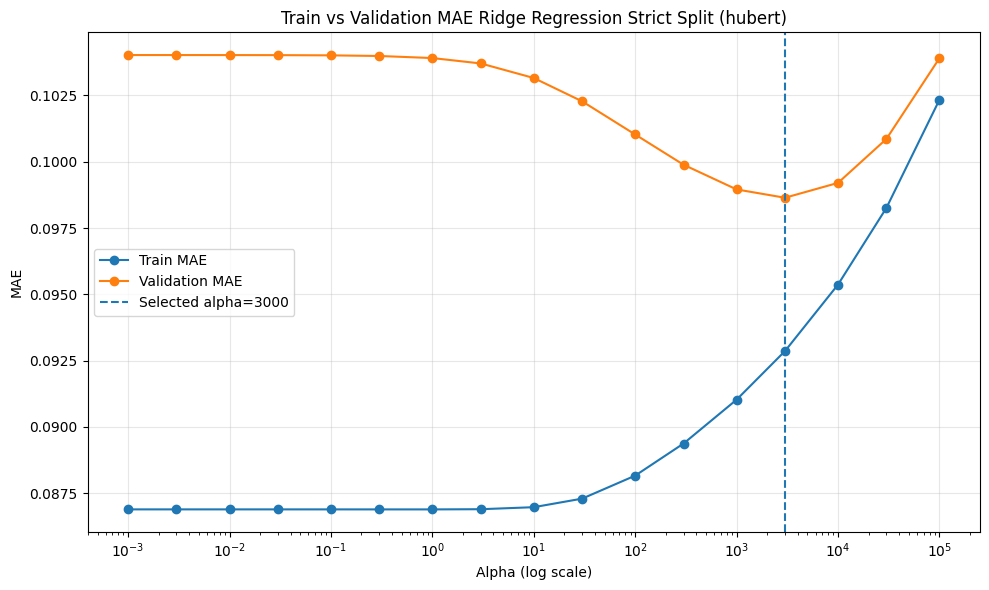

Saved figure: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\loss_curve_diagnostics\hubert\figures\hubert_strict_ridge_train_val_mae_vs_alpha.png


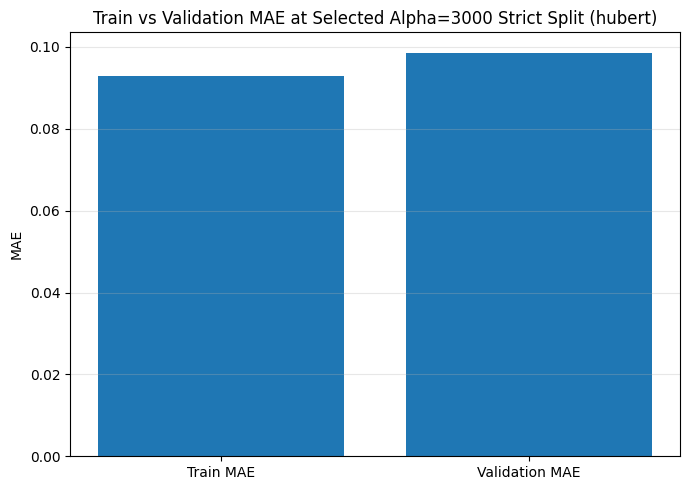

Saved figure: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\loss_curve_diagnostics\hubert\figures\hubert_strict_ridge_train_val_mae_selected_alpha.png
Saved selected alpha summary: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\loss_curve_diagnostics\hubert\hubert_strict_selected_alpha_error_summary.json


####################################################################################################
PROCESS STRICT METHOD: wav2vec2
####################################################################################################
[INFO] Menggunakan strict feature cache untuk wav2vec2: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\embeddings\wav2vec2
[wav2vec2] source train: X=(5936, 768), ids=5936
[wav2vec2] source val: X=(1999, 768), ids=1999
[wav2vec2] source test: X=(2039, 768), ids=2039
[wav2vec2] aligned strict train: (5936, 768)
[wav2vec2] aligned strict validation: (1999, 768)
[wav2vec2] aligned strict test: (2039, 768)

RUN RIDGE TRAI

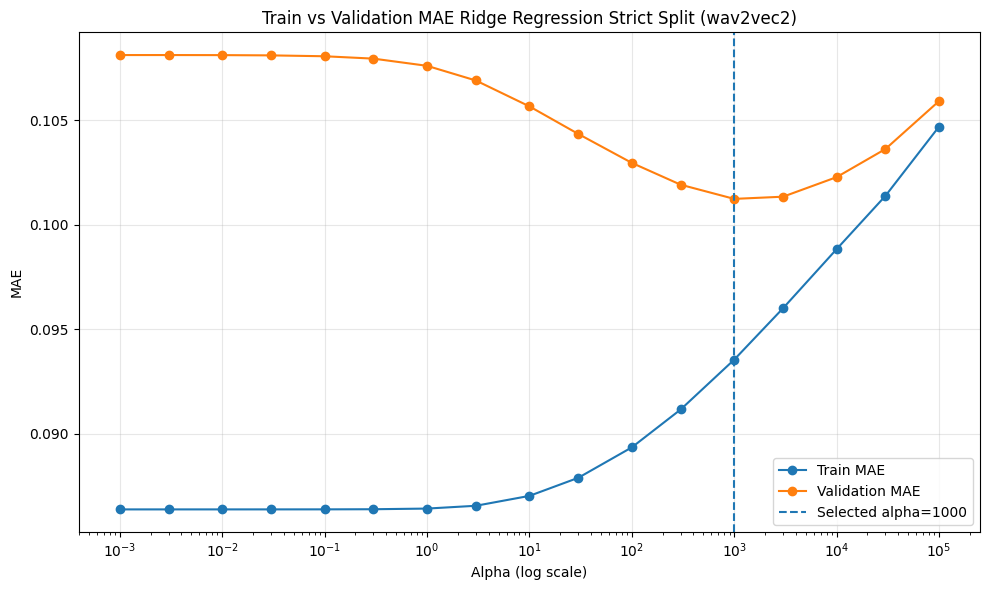

Saved figure: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\loss_curve_diagnostics\wav2vec2\figures\wav2vec2_strict_ridge_train_val_mae_vs_alpha.png


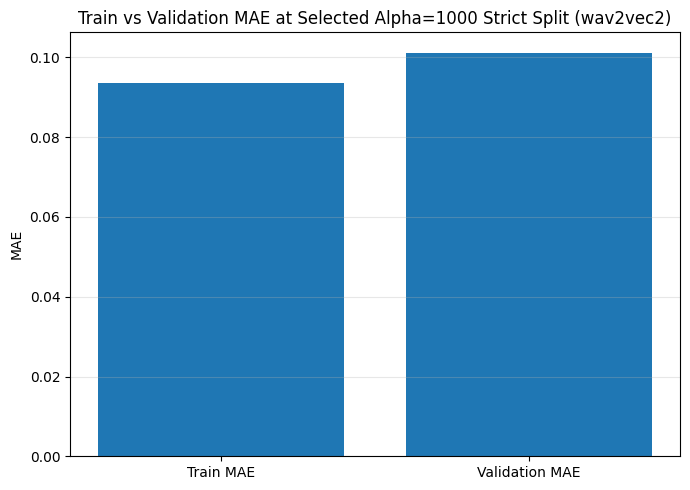

Saved figure: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\loss_curve_diagnostics\wav2vec2\figures\wav2vec2_strict_ridge_train_val_mae_selected_alpha.png
Saved selected alpha summary: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\loss_curve_diagnostics\wav2vec2\wav2vec2_strict_selected_alpha_error_summary.json


####################################################################################################
PROCESS STRICT METHOD: wavlm
####################################################################################################
[INFO] Menggunakan strict feature cache untuk wavlm: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\embeddings\wavlm
[wavlm] source train: X=(5936, 768), ids=5936
[wavlm] source val: X=(1999, 768), ids=1999
[wavlm] source test: X=(2039, 768), ids=2039
[wavlm] aligned strict train: (5936, 768)
[wavlm] aligned strict validation: (1999, 768)
[wavlm] aligned strict test: (2039, 768)

RUN RIDGE TRAIN-VALIDATION ERROR 

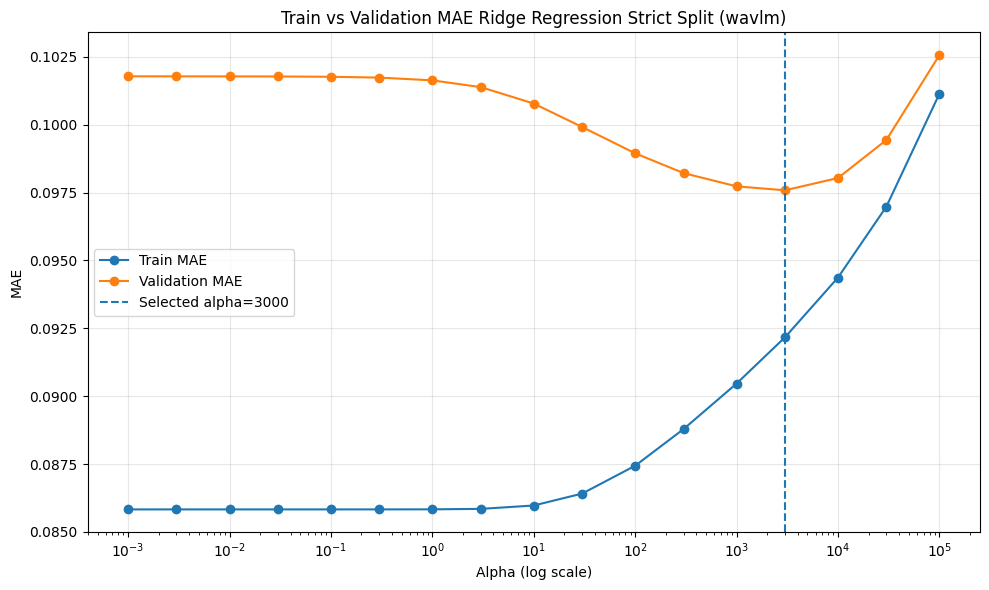

Saved figure: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\loss_curve_diagnostics\wavlm\figures\wavlm_strict_ridge_train_val_mae_vs_alpha.png


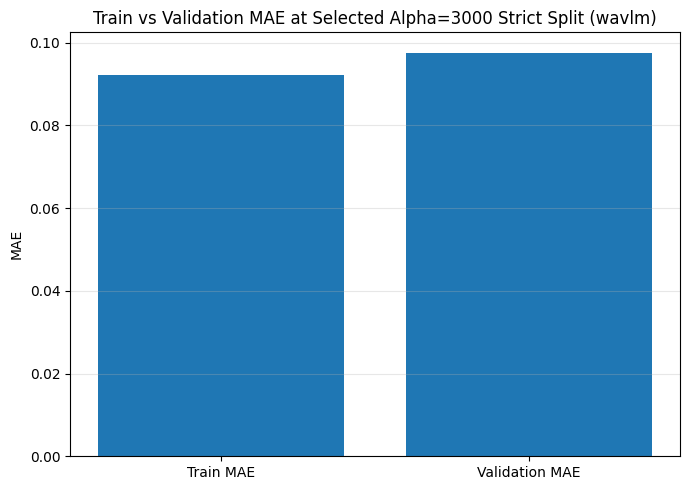

Saved figure: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\loss_curve_diagnostics\wavlm\figures\wavlm_strict_ridge_train_val_mae_selected_alpha.png
Saved selected alpha summary: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\loss_curve_diagnostics\wavlm\wavlm_strict_selected_alpha_error_summary.json


####################################################################################################
PROCESS STRICT METHOD: egemaps
####################################################################################################
[INFO] Menggunakan strict eGeMAPS cache: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\egemaps
eGeMAPS pool: (9974, 88)
Jumlah fitur eGeMAPS: 88
[egemaps] aligned strict train: (5936, 88)
[egemaps] aligned strict validation: (1999, 88)
[egemaps] aligned strict test: (2039, 88)

RUN RIDGE TRAIN-VALIDATION ERROR CURVE STRICT SPLIT: egemaps
alpha=    0.001 | train MAE=0.102141 | val MAE=0.106923 | train RMSE=0.128424 | val R

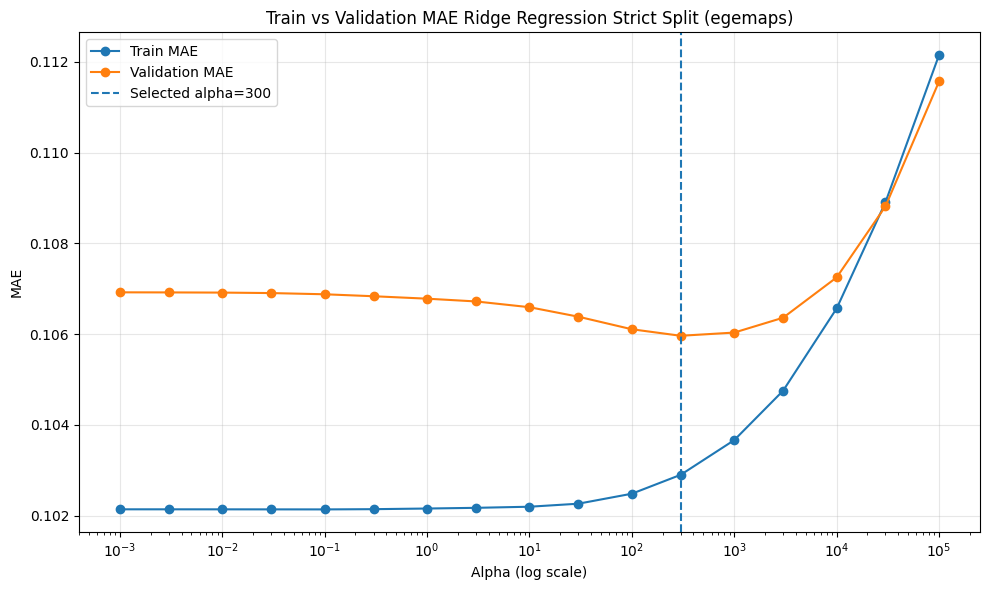

Saved figure: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\loss_curve_diagnostics\egemaps\figures\egemaps_strict_ridge_train_val_mae_vs_alpha.png


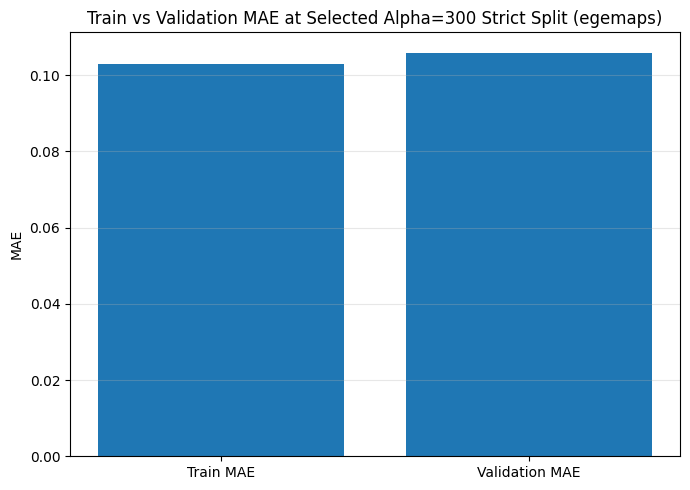

Saved figure: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\loss_curve_diagnostics\egemaps\figures\egemaps_strict_ridge_train_val_mae_selected_alpha.png
Saved selected alpha summary: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\loss_curve_diagnostics\egemaps\egemaps_strict_selected_alpha_error_summary.json

DONE.
Combined error CSV: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\loss_curve_diagnostics\combined_strict_ridge_train_val_error_alpha_sweep.csv
Selected alpha summary: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\loss_curve_diagnostics\selected_alpha_error_summary_all_methods_strict.csv


,split,method,selected_alpha,train_MAE,val_MAE,train_RMSE,val_RMSE,train_R2,val_R2,train_Acc(1-MAE),val_Acc(1-MAE)
0,strict,hubert,3000.0,0.092860,0.098642,0.116681,0.124451,0.362580,0.263530,0.907140,0.901358
1,strict,wav2vec2,1000.0,0.093541,0.101230,0.117546,0.127404,0.353511,0.228406,0.906459,0.898770
2,strict,wavlm,3000.0,0.092169,0.097582,0.116018,0.122693,0.369705,0.283911,0.907831,0.902418
3,strict,egemaps,300.0,0.102901,0.105965,0.129346,0.133390,0.219536,0.156002,0.897099,0.894035


In [9]:
# =========================
# BLOCK 9: RUN RIDGE ERROR CURVE DIAGNOSTICS FOR ALL METHODS
# =========================

METHODS_TO_RUN = [
    "hubert",
    "wav2vec2",
    "wavlm",
    "egemaps",
]

all_error_dfs = []
selected_alpha_summaries = []

for method in METHODS_TO_RUN:
    print("\n\n" + "#" * 100)
    print(f"PROCESS STRICT METHOD: {method}")
    print("#" * 100)

    if method in ["hubert", "wav2vec2", "wavlm"]:
        X_train, X_val, X_test = load_ssl_strict_pool(method)
    elif method == "egemaps":
        X_train, X_val, X_test = load_egemaps_strict_pool()
    else:
        raise ValueError(f"Unknown method: {method}")

    error_df, best_alpha_by_val_mae, method_out_dir, method_fig_dir = run_ridge_error_curve(
        method_name=method,
        X_train=X_train,
        X_val=X_val,
        X_test=X_test,
    )

    # Alpha efektif sesuai eksperimen baseline:
    # alpha dipilih berdasarkan validation MAE pada strict split.
    selected_alpha = best_alpha_by_val_mae

    plot_mae_curve(
        error_df=error_df,
        method_name=method,
        selected_alpha=selected_alpha,
        fig_dir=method_fig_dir,
    )

    selected_summary = plot_selected_alpha_bar(
        error_df=error_df,
        method_name=method,
        selected_alpha=selected_alpha,
        fig_dir=method_fig_dir,
    )

    all_error_dfs.append(error_df)
    selected_alpha_summaries.append(selected_summary)

combined_error_df = pd.concat(all_error_dfs, ignore_index=True)
combined_error_path = OUT_DIR / "combined_strict_ridge_train_val_error_alpha_sweep.csv"
combined_error_df.to_csv(combined_error_path, index=False)

selected_summary_df = pd.DataFrame(selected_alpha_summaries)
selected_summary_path = OUT_DIR / "selected_alpha_error_summary_all_methods_strict.csv"
selected_summary_df.to_csv(selected_summary_path, index=False)

print("\nDONE.")
print("Combined error CSV:", combined_error_path)
print("Selected alpha summary:", selected_summary_path)

display(selected_summary_df)


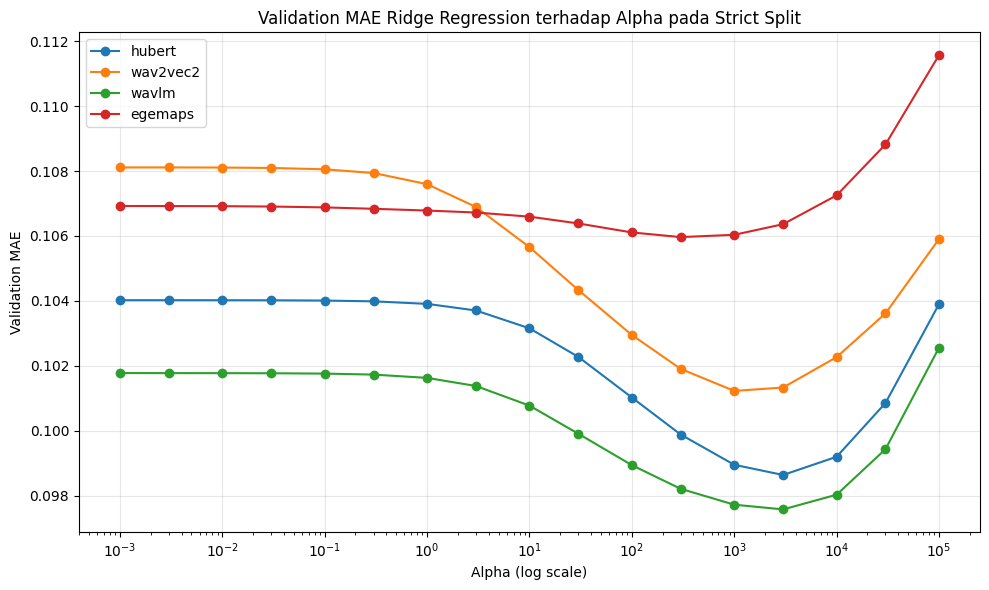

Saved figure: E:\AnotherPunyaQQ\tugas-akhir-qq\output\V2\baseline_strict\loss_curve_diagnostics\figures\combined_strict_validation_mae_vs_alpha.png


In [10]:
# =========================
# BLOCK 10: COMBINED VALIDATION MAE CURVE
# =========================

plt.figure(figsize=(10, 6))

for method in METHODS_TO_RUN:
    d = combined_error_df[combined_error_df["method"] == method].sort_values("alpha")
    plt.plot(
        d["alpha"],
        d["val_MAE"],
        marker="o",
        label=method
    )

plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Validation MAE")
plt.title("Validation MAE Ridge Regression terhadap Alpha pada Strict Split")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

save_path = FIG_DIR / "combined_strict_validation_mae_vs_alpha.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", save_path)


In [11]:
# =========================
# BLOCK 11: AUTO SUMMARY FOR THESIS TEXT
# =========================

summary_lines = []

summary_lines.append("Ringkasan diagnostic train-validation error Ridge Regression pada strict split")
summary_lines.append("=" * 78)
summary_lines.append("")
summary_lines.append(
    "Karena Ridge Regression tidak dilatih secara epoch-based seperti neural network, "
    "kurva loss per epoch tidak tersedia. Sebagai pengganti, analisis train-validation "
    "ditampilkan terhadap variasi nilai alpha. Setiap titik pada kurva merepresentasikan "
    "satu model Ridge yang dilatih dengan nilai alpha tertentu."
)
summary_lines.append("")
summary_lines.append(
    "Galat yang digunakan pada kurva utama adalah MAE, karena MAE merupakan metrik evaluasi "
    "utama pada penelitian ini dan juga digunakan sebagai dasar pemilihan alpha terbaik pada "
    "validation set. Dengan demikian, kurva ini digunakan untuk melihat pengaruh regularisasi "
    "terhadap performa train dan validation pada strict split, bukan sebagai riwayat loss internal per epoch."
)
summary_lines.append("")

for _, row in selected_summary_df.iterrows():
    summary_lines.append(
        f"- {row['method']}: selected alpha={row['selected_alpha']:g}, "
        f"train MAE={row['train_MAE']:.6f}, "
        f"validation MAE={row['val_MAE']:.6f}, "
        f"train RMSE={row['train_RMSE']:.6f}, "
        f"validation RMSE={row['val_RMSE']:.6f}, "
        f"train R2={row['train_R2']:.6f}, "
        f"validation R2={row['val_R2']:.6f}, "
        f"train Acc(1-MAE)={row['train_Acc(1-MAE)']:.6f}, "
        f"validation Acc(1-MAE)={row['val_Acc(1-MAE)']:.6f}."
    )

summary_text = "\n".join(summary_lines)

summary_path = OUT_DIR / "strict_ridge_error_curve_diagnostic_summary.txt"
summary_path.write_text(summary_text, encoding="utf-8")

print(summary_text)
print("\nSaved summary:", summary_path)


Ringkasan diagnostic train-validation error Ridge Regression pada strict split

Karena Ridge Regression tidak dilatih secara epoch-based seperti neural network, kurva loss per epoch tidak tersedia. Sebagai pengganti, analisis train-validation ditampilkan terhadap variasi nilai alpha. Setiap titik pada kurva merepresentasikan satu model Ridge yang dilatih dengan nilai alpha tertentu.

Galat yang digunakan pada kurva utama adalah MAE, karena MAE merupakan metrik evaluasi utama pada penelitian ini dan juga digunakan sebagai dasar pemilihan alpha terbaik pada validation set. Dengan demikian, kurva ini digunakan untuk melihat pengaruh regularisasi terhadap performa train dan validation pada strict split, bukan sebagai riwayat loss internal per epoch.

- hubert: selected alpha=3000, train MAE=0.092860, validation MAE=0.098642, train RMSE=0.116681, validation RMSE=0.124451, train R2=0.362580, validation R2=0.263530, train Acc(1-MAE)=0.907140, validation Acc(1-MAE)=0.901358.
- wav2vec2: select